# Word Embedding and NLP with TF 2.0 and Keras on Twitter Sentiment Data

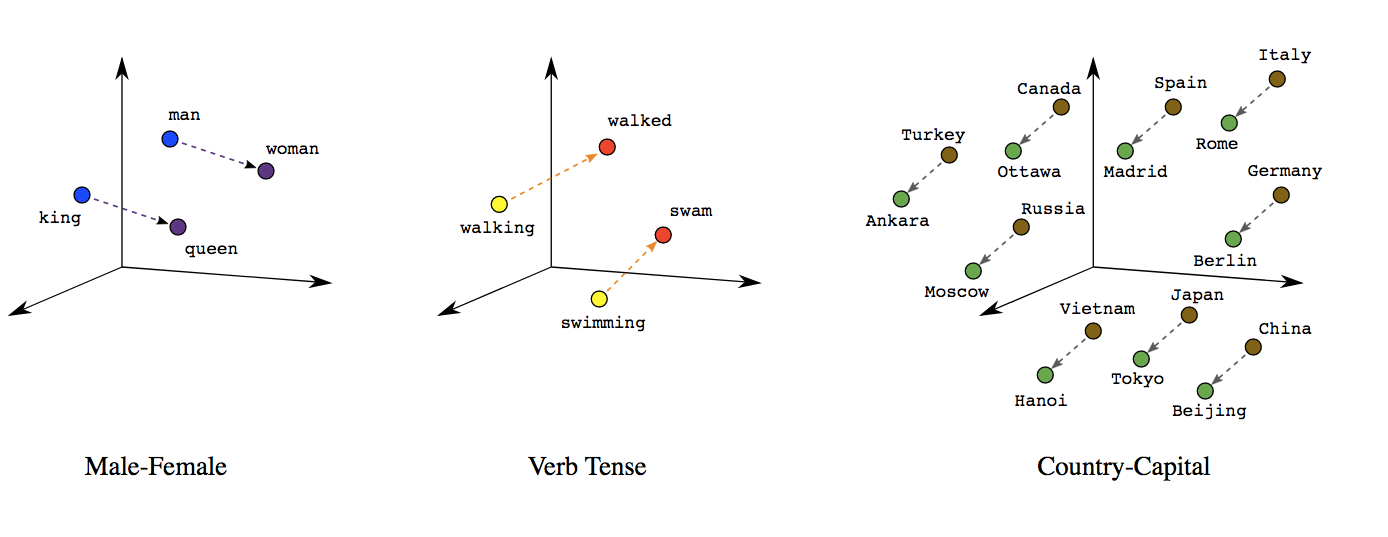

* Dataset1: https://www.kaggle.com/datasets/kazanova/sentiment140/data
* Dataset2: https://raw.githubusercontent.com/laxmimerit/twitter-data/refs/heads/master/twitter4000.csv

In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer, one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Flatten, Activation, Dropout
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D
import numpy as np
import pandas as pd
from numpy import asarray
from numpy import zeros
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/twitter-data/refs/heads/master/twitter4000.csv')
df.head()

,twitts,sentiment
0,is bored and wants to watch a movie any sugge...,0
1,back in miami. waiting to unboard ship,0
2,"@misskpey awwww dnt dis brng bak memoriessss, ...",0
3,ughhh i am so tired blahhhhhhhhh,0
4,@mandagoforth me bad! It's funny though. Zacha...,0


In [3]:
df['sentiment'].value_counts()

,count
sentiment,
0,2000
1,2000


In [4]:
text = df['twitts'].tolist()
text[:20]

['is bored and wants to watch a movie  any suggestions?',
 'back in miami.  waiting to unboard ship ',
 "@misskpey awwww dnt dis brng bak memoriessss,  I thnk I'm sad. LoL",
 'ughhh i am so tired  blahhhhhhhhh',
 "@mandagoforth me bad! It's funny though. Zachary Quinto is only there for a few though.  &amp; to reply just put the @ symbol before the name!",
 "brr, i'm so cold. at the moment doing my assignment on Huntington's Disease, which is really depressing ",
 "@kevinmarquis haha yep but i really need to sleep, i feel like crap lol cant sleep when he's away  god i'm pathetic!",
 "eating some ice-cream while I try to see @peterfacinelli's followers numbre raise...not working sadly ",
 '@phatty84 just hella bored at work  lol',
 'Food poisoning blowssss ',
 "@StaciG She sent home the best guy, I'm over the show already ",
 '@shika Yeah I did. Trying to recover it now. I guess its time to retire that hardware ',
 "can't fall asleep ",
 'Padres come back from being down 6-0 &amp; we lo

In [5]:
y = df['sentiment'].tolist()
y[:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [6]:
token = Tokenizer()
token.fit_on_texts(text)

In [7]:
token

In [8]:
vocab = token.index_word # unique words

for key, value in list(token.index_word.items())[:20]:
  print(f"{key}: {value}")

1: i
2: to
3: the
4: a
5: my
6: and
7: you
8: is
9: it
10: in
11: for
12: of
13: me
14: on
15: so
16: that
17: i'm
18: have
19: at
20: but


In [9]:
len(token.word_index)

10134

In [10]:
vocab_size = len(token.word_index) + 1

In [11]:
# x = [1, 2, 3, 4, 6]
x = ["i to the a and"]
token.texts_to_sequences(x)

[[1, 2, 3, 4, 6]]

In [12]:
encoded_text = token.texts_to_sequences(text)
encoded_text[:5]

[[8, 304, 6, 345, 2, 191, 4, 236, 254, 3079],
 [52, 10, 1019, 206, 2, 3080, 3081],
 [3082, 1197, 668, 1955, 3083, 1956, 3084, 1, 3085, 17, 115, 44],
 [1957, 1, 62, 15, 192, 3086],
 [3087,
  13,
  113,
  47,
  328,
  136,
  3088,
  3089,
  8,
  101,
  88,
  11,
  4,
  285,
  136,
  48,
  2,
  448,
  21,
  277,
  3,
  3090,
  218,
  3,
  449]]

In [13]:
max_length = 120
X = pad_sequences(encoded_text, maxlen=max_length, padding='post')
X[:5]

array([[   8,  304,    6,  345,    2,  191,    4,  236,  254, 3079,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [  52,   10, 1019,  206,    2, 3080, 3081,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,

In [14]:
X.shape

(4000, 120)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
type(X_train), type(y_train), type(X_test), type(y_test)

(numpy.ndarray, list, numpy.ndarray, list)

In [18]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

y_train = np.array(y_train).astype(np.float32) # Önce NumPy dizisine dönüştür, sonra tipi ayarla
y_test = np.array(y_test).astype(np.float32)   # Önce NumPy dizisine dönüştür, sonra tipi ayarla

y_train = np.asarray(y_train).reshape(-1,) #Bu satirlar gereksiz çünkü numpy dizisine çevirdik
y_test = np.asarray(y_test).reshape(-1,) #Bu satirlar gereksiz çünkü numpy dizisine çevirdik

In [19]:
vec_size = 300
model = Sequential()
model.add(Embedding(vocab_size, vec_size, input_length=max_length))

model.add(Conv1D(64, 8, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(16, activation='relu'))

model.add(GlobalMaxPooling1D())

model.add(Dense(1, activation='sigmoid'))

In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [22]:
%%time
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.5006 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.4993 - loss: 0.6953 - val_accuracy: 0.5025 - val_loss: 0.6936
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.5201 - loss: 0.6926 - val_accuracy: 0.6200 - val_loss: 0.6524
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.6937 - loss: 0.5948 - val_accuracy: 0.7150 - val_loss: 0.5484
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.8690 - loss: 0.3385 - val_accuracy: 0.7212 - val_loss: 0.5766
CPU times: user 1min 48s, sys: 4.65 s, total: 1min 53s
Wall time: 1min 37s


In [26]:
def get_encoded(x):
  x = token.texts_to_sequences(x)
  x = pad_sequences(x, maxlen=max_length, padding='post')
  return x


In [31]:
x = ["worst services. will not come again"] # negative sentiment
model.predict(get_encoded(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[0.10296145]], dtype=float32)

In [34]:
x = ["good services. i will come again"] # positive sentiment
model.predict(get_encoded(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.7326781]], dtype=float32)

In [40]:
x = ["i love my job and my family very very much"] # positive sentiment
model.predict(get_encoded(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


array([[0.81297165]], dtype=float32)